In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df.shape

(555278, 86)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
df_exclude_object['Label'].value_counts()

0    517582
1     37696
Name: Label, dtype: int64

In [ ]:
df_exclude_object.shape

(555278, 82)

In [ ]:
df_exclude_object.head(5)

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Label
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,1
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,...,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,1
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,...,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,1
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,...,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,1
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,...,126016.885411,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,1


In [ ]:
from sklearn.model_selection import train_test_split
X = df_exclude_object.iloc[:,:-1]
y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

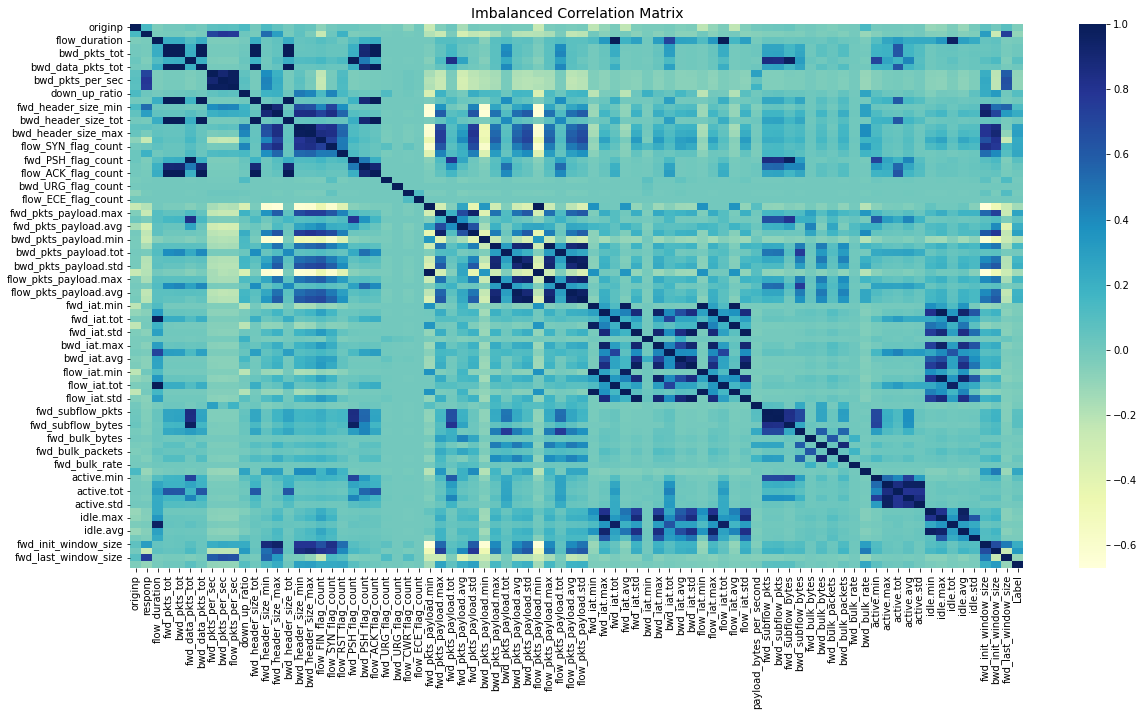

In [ ]:
# Sample figsize in inches
fig, ax = plt.subplots(figsize=(20,10))
# Imbalanced DataFrame Correlation
corr = df_exclude_object.corr()
sns.heatmap(corr, cmap='YlGnBu', annot_kws={'size':30}, ax=ax)
ax.set_title("Imbalanced Correlation Matrix", fontsize=14)
plt.show()

#Cross Validation K-Fold
menggunakan KFold 10 sesuai dengan jurnal, untuk mencegah overfitting

https://grabngoinfo.com/ensemble-oversampling-and-under-sampling-for-imbalanced-classification-using-python/

https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6#:~:text=In%20order%20to%20avoid%20this,1%20one%20of%20those%20subset.

yang saya pakai:
https://vitalflux.com/k-fold-cross-validation-python-example/

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
kf = StratifiedKFold(n_splits=10)
kfolds = kf.split(X_train, y_train)
scores = []

#Classifications
memakai x_pca sebagai x_train kita

##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=3000)

In [ ]:
for k, (train, test) in enumerate(kfolds):
    logmodel.fit(X_train.iloc[train, :], y_train.iloc[train])
    score = logmodel.score(X_train.iloc[test, :], y_train.iloc[test])
    scores.append(score)
    print('Fold: %2d, Training/Test Split Distribution: %s, Accuracy: %.3f' % (k+1, np.bincount(y_train.iloc[train]), score))

print('\n\nCross-Validation accuracy: %.3f +/- %.3f' %(np.mean(scores), np.std(scores)))

/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold:  1, Training/Test Split Distribution: [325912  23912], Accuracy: 0.926


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold:  2, Training/Test Split Distribution: [325912  23912], Accuracy: 0.927


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold:  7, Training/Test Split Distribution: [325913  23912], Accuracy: 0.927


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold:  8, Training/Test Split Distribution: [325913  23912], Accuracy: 0.923
Fold:  9, Training/Test Split Distribution: [325913  23912], Accuracy: 0.929


Cross-Validation accuracy: 0.927 +/- 0.002


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [ ]:
predLR = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predLR))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97    155457
           1       0.04      0.00      0.00     11127

    accuracy                           0.93    166584
   macro avg       0.49      0.50      0.48    166584
weighted avg       0.87      0.93      0.90    166584



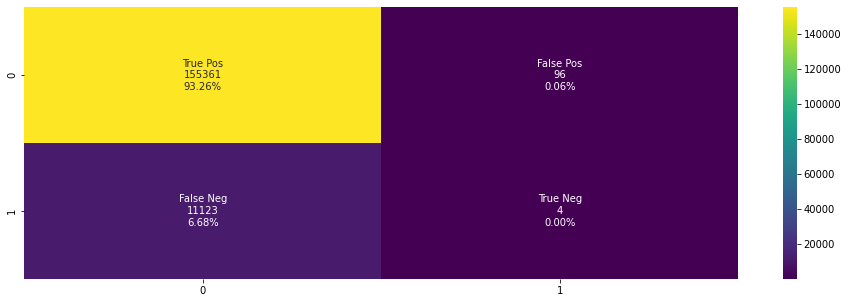

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predLR)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##KNN Classifier
menggunakan n_neighbors default

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
predKNN = knn.predict(X_test)

In [ ]:
print(classification_report(y_test, predKNN))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95    155457
           1       0.28      0.20      0.23     11127

    accuracy                           0.91    166584
   macro avg       0.61      0.58      0.59    166584
weighted avg       0.90      0.91      0.91    166584



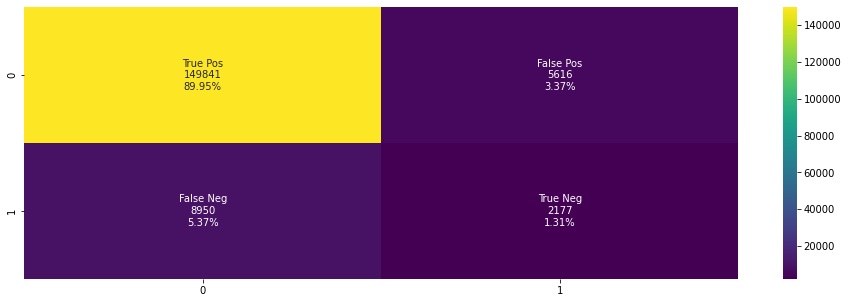

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predKNN)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

## Decision Tree dan Random Forest
max_depth default, n_estimators default

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dtree = DecisionTreeClassifier()

In [ ]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
predDtree = dtree.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test, predDtree))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    155457
           1       0.11      0.10      0.11     11127

    accuracy                           0.88    166584
   macro avg       0.52      0.52      0.52    166584
weighted avg       0.88      0.88      0.88    166584



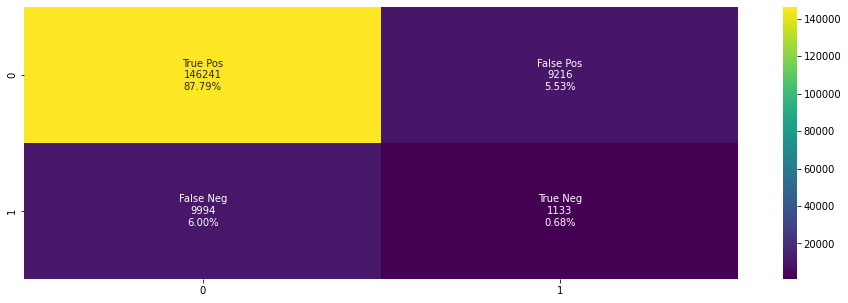

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predDtree)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
predRFC = rfc.predict(X_test)

In [ ]:
print(classification_report(y_test, predRFC))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    155457
           1       0.15      0.14      0.14     11127

    accuracy                           0.89    166584
   macro avg       0.54      0.54      0.54    166584
weighted avg       0.89      0.89      0.89    166584



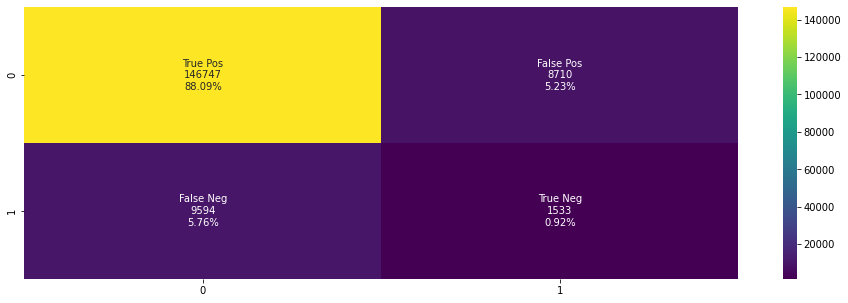

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predRFC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##Naive Bayes: Gaussian Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Build a Gaussian Classifier
nbgc = GaussianNB()

In [ ]:
# Model training
nbgc.fit(X_train, y_train)

# Predict Output
predNBGC = nbgc.predict(X_test)

In [ ]:
print(classification_report(y_test, predNBGC))

              precision    recall  f1-score   support

           0       0.99      0.37      0.54    155457
           1       0.10      0.95      0.18     11127

    accuracy                           0.41    166584
   macro avg       0.54      0.66      0.36    166584
weighted avg       0.93      0.41      0.52    166584



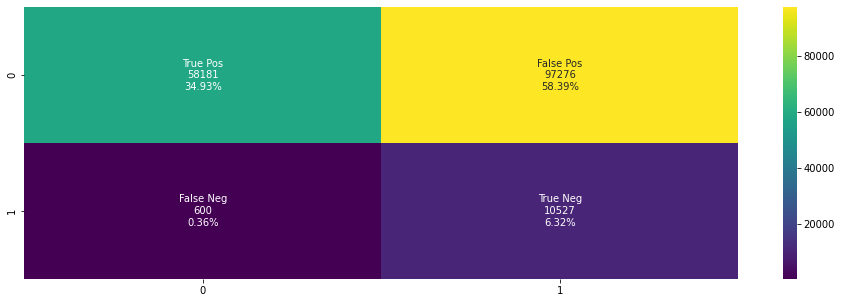

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predNBGC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC()
'''
generalization:
low C = high bias, low variance
high C = low bias, low variance

low gamma = high variance
high gamma = low variance

gamma ada tergantung rbf
'''

'\ngeneralization:\nlow C = high bias, low variance\nhigh C = low bias, low variance\n\nlow gamma = high variance\nhigh gamma = low variance\n\ngamma ada tergantung rbf\n'

In [ ]:
svc.fit(X_train, y_train)

SVC()

In [ ]:
pred_svc = svc.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97    155457
           1       0.48      0.04      0.07     11127

    accuracy                           0.93    166584
   macro avg       0.71      0.52      0.52    166584
weighted avg       0.90      0.93      0.91    166584



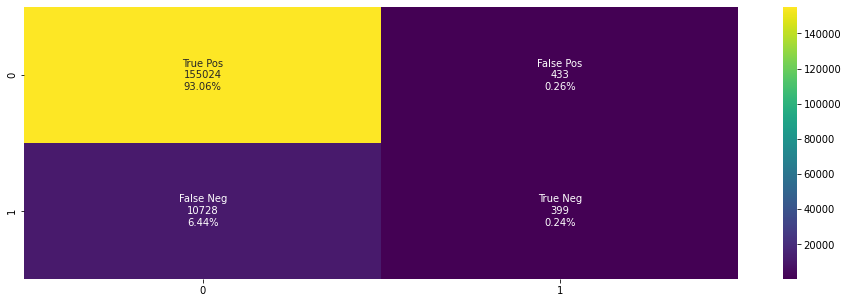

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, pred_svc)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');